# Stage 4 — SimCSE Unsupervised Contrastive Training
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 4 of 12  
**Notebook:** `04_simcse_training.ipynb`

### Konsep SimCSE
SimCSE (Simple Contrastive Sentence Embeddings) adalah pendekatan contrastive learning **tanpa labeled data**.

**Key insight:** Passing the same sentence through an encoder **twice** dengan **dropout mask berbeda** menghasilkan dua embedding yang sedikit berbeda — ini dipakai sebagai **positive pair**. Semua kalimat lain dalam batch menjadi **in-batch negatives**.

```
Kalimat: "Seorang pria bermain gitar."
  → Encoder (dropout_1) → embedding_a  ┐
  → Encoder (dropout_2) → embedding_b  ┘ positive pair
  
  Semua embedding lain dalam batch = negatives
  Loss: MultipleNegativesRankingLoss
```

**Kenapa efektif:**
- Menghindari anisotropy problem (embeddings terpusat di satu region)
- Distribusi embedding lebih uniform di hypersphere
- Tidak butuh label — hanya butuh kalimat-kalimat tidak berlabel

### Cell Structure
```
4.0    Bootstrap
4.0b   Imports
4.1    Load SimCSE corpus
4.2    Build model & DataLoader
4.3    Training SimCSE
4.4    Evaluasi: Pearson & Spearman vs Baseline
4.5    Evaluasi per kategori
4.6    Simpan SimCSE model & embeddings
4.7    Simpan hasil evaluasi
4.8    Sanity check
```

### Output
```
models/simcse/
embeddings/simcse_val_emb_s1/s2.npy
embeddings/simcse_test_emb_s1/s2.npy
evaluation/simcse_results.json
experiments/simcse/eval_log.csv
experiments/simcse/training_loss.png
```
---

In [1]:
# ============================================================
# CELL 4.0 - Bootstrap
# ============================================================

import sys, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR

os.environ["HF_HOME"]                = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"]     = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# HF Login
from google.colab import userdata
try:
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'), add_to_git_credential=False)
    print("[OK] HF login berhasil.")
except Exception as e:
    print(f"[WARN] HF login: {e}")

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[OK] Device : {DEVICE}")
if DEVICE == "cuda":
    print(f"     GPU    : {torch.cuda.get_device_name(0)}")
    print(f"     VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
elif DEVICE == "cpu":
    print("     [WARN] CPU mode — training akan sangat lambat (~3-4 jam).")
    print("            Aktifkan GPU: Runtime -> Change runtime type -> T4 GPU")

print(f"[OK] PROJECT_ROOT: {PROJECT_ROOT}")

Mounted at /content/drive
[OK] HF login berhasil.
[OK] Device : cuda
     GPU    : Tesla T4
     VRAM   : 15.6 GB
[OK] PROJECT_ROOT: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings


In [2]:
# ============================================================
# CELL 4.0b - Imports
# ============================================================

!pip install -q sentence-transformers transformers

import numpy as np
import pandas as pd
import json
import time
import datetime
import math
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from torch.utils.data import DataLoader

from sentence_transformers import (
    SentenceTransformer, InputExample,
    models, losses, evaluation
)
from src.data_loader import (
    load_splits, load_simcse_corpus,
    df_to_simcse_examples, print_split_summary
)

plt.rcParams['figure.dpi'] = 120
print("[OK] Imports selesai.")

[OK] Imports selesai.


In [3]:
from project_config import PATHS
for k in ['simcse_model', 'simcse_exp', 'embeddings']:
    print(f"  {'OK' if k in PATHS else 'MISSING'} — PATHS['{k}']")

  OK — PATHS['simcse_model']
  OK — PATHS['simcse_exp']
  OK — PATHS['embeddings']


In [4]:
# ============================================================
# CELL 4.1 - Load SimCSE Corpus
# ============================================================
# SimCSE corpus = semua kalimat unik dari train set (tanpa label)
# Di-build di Stage 2 Cell 2.6b -> datasets/splits/simcse_sentences.txt

print("[INFO] Loading SimCSE corpus & dataset splits...\n")

# -- Load corpus untuk training
simcse_sentences = load_simcse_corpus(
    PATHS['splits'] / 'simcse_sentences.txt',
    max_sentences=None,   # pakai semua
    shuffle=True,
    seed=42
)

# -- Load splits untuk evaluasi
data = load_splits(PATHS['splits'])
df_train = data['train']
df_val   = data['val']
df_test  = data['test']

print(f"\n  SimCSE corpus  : {len(simcse_sentences):,} sentences")
print(f"  Train pairs    : {len(df_train):,}")
print(f"  Val pairs      : {len(df_val):,}")
print(f"  Test pairs     : {len(df_test):,}")

print(f"\n  Sample 3 kalimat corpus:")
for s in simcse_sentences[:3]:
    print(f"    - {s[:75]}")

[INFO] Loading SimCSE corpus & dataset splits...

[OK] 10,373 sentences for SimCSE.
[OK] train: 5,696 pairs  score [0.000 - 1.000]
[OK] val: 2,994 pairs  score [0.000 - 1.000]
[OK] test: 1,372 pairs  score [0.000 - 1.000]

  SimCSE corpus  : 10,373 sentences
  Train pairs    : 5,696
  Val pairs      : 2,994
  Test pairs     : 1,372

  Sample 3 kalimat corpus:
    - Israel diminta untuk mempertimbangkan rencana penyelesaian terbaru dari neg
    - Grassley dan Baucus mengatakan mereka menolak pendekatan itu dalam rencana 
    - Sweeney adalah untuk menguraikan rencana untuk kampanye dalam pidato pada S


In [5]:
# ============================================================
# CELL 4.2 - Build Model & DataLoader
# ============================================================
# SimCSE menggunakan arsitektur yang sama dengan baseline:
#   IndoBERT + Mean Pooling
# Perbedaan: encoder weights akan di-update dengan
#   MultipleNegativesRankingLoss (contrastive objective)

# ── Hyperparameters ──────────────────────────────────────────
# Nilai ini mengikuti SimCSE paper (Gao et al., 2021)
# dengan adjustment untuk dataset size Indonesian

BATCH_SIZE  = 64    # SimCSE paper: 64. Kurangi ke 32 jika OOM.
NUM_EPOCHS  = 1     # SimCSE converges in 1 epoch (paper finding)
WARMUP_RATIO = 0.1  # 10% warmup steps
LR           = 3e-5 # learning rate standar untuk BERT fine-tuning
MAX_SEQ_LEN  = 128

print("[INFO] Building SimCSE model...")

# -- Build SentenceTransformer (sama dengan baseline)
word_emb = models.Transformer(
    model_name_or_path="indobenchmark/indobert-base-p1",
    max_seq_length=MAX_SEQ_LEN,
    do_lower_case=False
)
pooling = models.Pooling(
    word_emb.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)
simcse_model = SentenceTransformer(
    modules=[word_emb, pooling],
    device=DEVICE
)

# -- Build SimCSE InputExamples
# texts=[sent, sent] — kalimat yang sama dua kali
# Dropout berbeda tiap forward pass = augmentasi positif
print("[INFO] Building SimCSE training examples...")
train_examples = df_to_simcse_examples(simcse_sentences)

train_dataloader = DataLoader(
    train_examples,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -- Loss function: MultipleNegativesRankingLoss
# In-batch contrastive: setiap sample lain di batch = negative
# Scale=20.0 sesuai SimCSE paper (temperature = 1/scale = 0.05)

train_loss = losses.MultipleNegativesRankingLoss(
    model=simcse_model,
    scale=20.0
)
# Fallback jika SiameseDistanceMetric tidak ada
if train_loss is None:
    train_loss = losses.MultipleNegativesRankingLoss(
        model=simcse_model,
        scale=20.0
    )

# -- Evaluator untuk monitor progress selama training
evaluator = evaluation.EmbeddingSimilarityEvaluator(
    df_val['sentence1'].tolist(),
    df_val['sentence2'].tolist(),
    df_val['score'].tolist(),
    name='simcse_val',
    show_progress_bar=False
)

total_steps  = len(train_dataloader) * NUM_EPOCHS
warmup_steps = math.ceil(total_steps * WARMUP_RATIO)

print(f"\n  Model           : indobenchmark/indobert-base-p1")
print(f"  Training mode   : SimCSE (unsupervised contrastive)")
print(f"  Corpus size     : {len(simcse_sentences):,} sentences")
print(f"  Train examples  : {len(train_examples):,} (same sentence twice)")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Total steps     : {total_steps:,}")
print(f"  Warmup steps    : {warmup_steps:,}")
print(f"  Learning rate   : {LR}")
print(f"  Loss            : MultipleNegativesRankingLoss (scale=20)")
print(f"  Device          : {DEVICE}")

if DEVICE == "cuda":
    est_min = total_steps * 0.15 / 60
else:
    est_min = total_steps * 3.0 / 60
print(f"  Est. time       : ~{est_min:.0f} menit ({DEVICE})")

[INFO] Building SimCSE model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[INFO] Building SimCSE training examples...

  Model           : indobenchmark/indobert-base-p1
  Training mode   : SimCSE (unsupervised contrastive)
  Corpus size     : 10,373 sentences
  Train examples  : 10,373 (same sentence twice)
  Batch size      : 64
  Epochs          : 1
  Total steps     : 163
  Warmup steps    : 17
  Learning rate   : 3e-05
  Loss            : MultipleNegativesRankingLoss (scale=20)
  Device          : cuda
  Est. time       : ~0 menit (cuda)


In [8]:
# ============================================================
# CELL 4.3 - Training SimCSE [PATCHED]
# ============================================================

SIMCSE_OUTPUT = PATHS['simcse_model']
SIMCSE_OUTPUT.mkdir(parents=True, exist_ok=True)

SIMCSE_EXP = PATHS['simcse_exp']
SIMCSE_EXP.mkdir(parents=True, exist_ok=True)

print("[INFO] Starting SimCSE training...")
print(f"       Output: {SIMCSE_OUTPUT}\n")

# Cek versi sentence-transformers untuk compatibility
import sentence_transformers as st_pkg
import inspect
st_version = st_pkg.__version__
print(f"[INFO] sentence-transformers version: {st_version}")

# Cek parameter yang tersedia di model.fit()
fit_params = inspect.signature(simcse_model.fit).parameters.keys()
print(f"[INFO] fit() params tersedia: {list(fit_params)}\n")

t_start = time.time()

# Base fit kwargs — selalu tersedia
fit_kwargs = dict(
    train_objectives  = [(train_dataloader, train_loss)],
    evaluator         = evaluator,
    epochs            = NUM_EPOCHS,
    warmup_steps      = warmup_steps,
    optimizer_params  = {'lr': LR},
    output_path       = str(SIMCSE_OUTPUT),
    show_progress_bar = True,
    evaluation_steps  = max(1, total_steps // 10),
)

# Parameter opsional — tambahkan hanya jika tersedia
if 'save_best_only' in fit_params:
    fit_kwargs['save_best_only'] = True

if 'checkpoint_path' in fit_params:
    fit_kwargs['checkpoint_path']       = str(SIMCSE_EXP / 'checkpoints')
    fit_kwargs['checkpoint_save_steps'] = max(1, total_steps // 5)

simcse_model.fit(**fit_kwargs)

elapsed = time.time() - t_start
print(f"\n[OK] Training selesai dalam {elapsed/60:.1f} menit.")
print(f"     Model tersimpan di: {SIMCSE_OUTPUT}")

[INFO] Starting SimCSE training...
       Output: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/simcse

[INFO] sentence-transformers version: 5.2.3
[INFO] fit() params tersedia: ['train_objectives', 'evaluator', 'epochs', 'steps_per_epoch', 'scheduler', 'warmup_steps', 'optimizer_class', 'optimizer_params', 'weight_decay', 'evaluation_steps', 'output_path', 'save_best_model', 'max_grad_norm', 'use_amp', 'callback', 'show_progress_bar', 'checkpoint_path', 'checkpoint_save_steps', 'checkpoint_save_total_limit', 'resume_from_checkpoint']



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Simcse Val Pearson Cosine,Simcse Val Spearman Cosine
16,No log,No log,0.658802,0.657015
32,No log,No log,0.666489,0.668646
48,No log,No log,0.665358,0.668225
64,No log,No log,0.660728,0.665479
80,No log,No log,0.663042,0.667910
96,No log,No log,0.668146,0.672847
112,No log,No log,0.672477,0.675750
128,No log,No log,0.672094,0.675519
144,No log,No log,0.674533,0.677916
160,No log,No log,0.674827,0.678248


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OK] Training selesai dalam 5.8 menit.
     Model tersimpan di: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/simcse


In [9]:
# ============================================================
# CELL 4.4 - Evaluasi: Pearson & Spearman vs Baseline
# ============================================================

print("[INFO] Loading best SimCSE model untuk evaluasi...")
simcse_model_eval = SentenceTransformer(str(SIMCSE_OUTPUT), device=DEVICE)

def encode_and_eval(model, df, split_name):
    """
    Encode pairs dan hitung Pearson + Spearman correlation.
    Returns dict hasil evaluasi + cos_scores.
    """
    s1 = model.encode(
        df['sentence1'].tolist(),
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    s2 = model.encode(
        df['sentence2'].tolist(),
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    gold       = df['score'].values
    cos_scores = np.sum(s1 * s2, axis=1)
    pearson_r  = pearsonr(gold, cos_scores).statistic
    spearman_r = spearmanr(gold, cos_scores).statistic
    return {
        'split'     : split_name,
        'n_pairs'   : len(df),
        'pearson'   : round(float(pearson_r),  4),
        'spearman'  : round(float(spearman_r), 4),
        'emb_s1'    : s1,
        'emb_s2'    : s2,
        'cos_scores': cos_scores,
        'gold'      : gold,
    }

print("[INFO] Evaluating SimCSE model...")
val_res  = encode_and_eval(simcse_model_eval, df_val,  'val')
test_res = encode_and_eval(simcse_model_eval, df_test, 'test')

# -- Load baseline results untuk perbandingan
with open(PATHS['evaluation'] / 'baseline_results.json') as f:
    baseline_res = json.load(f)

baseline_val_sp  = baseline_res['val']['spearman']
baseline_test_sp = baseline_res['test']['spearman']

# -- Print comparison table
print(f"\n  {'='*55}")
print(f"  MODEL COMPARISON — BASELINE vs SimCSE")
print(f"  {'='*55}")
print(f"  {'Model':<28} {'Val Spearman':>13} {'Test Spearman':>14}")
print(f"  {'-'*55}")
print(f"  {'Zero-Shot Baseline':<28} {baseline_val_sp:>13.4f} {baseline_test_sp:>14.4f}")
print(f"  {'SimCSE (unsupervised)':<28} {val_res['spearman']:>13.4f} {test_res['spearman']:>14.4f}")
print(f"  {'-'*55}")
delta_val  = val_res['spearman']  - baseline_val_sp
delta_test = test_res['spearman'] - baseline_test_sp
print(f"  {'Delta (SimCSE - Baseline)':<28} {delta_val:>+13.4f} {delta_test:>+14.4f}")
print(f"  {'Target (SBERT goal)':<28} {'':>13} {'>=0.8000':>14}")
print(f"  {'Gap to target':<28} {'':>13} {0.80 - test_res['spearman']:>+14.4f}")
print(f"  {'='*55}")

if delta_test > 0:
    print(f"\n  [OK] SimCSE BEATS baseline by +{delta_test:.4f} Spearman")
else:
    print(f"\n  [WARN] SimCSE tidak beat baseline. Delta={delta_test:.4f}")
    print(f"         Cek training loss — mungkin overfitting atau learning rate terlalu besar.")

[INFO] Loading best SimCSE model untuk evaluasi...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[INFO] Evaluating SimCSE model...

  MODEL COMPARISON — BASELINE vs SimCSE
  Model                         Val Spearman  Test Spearman
  -------------------------------------------------------
  Zero-Shot Baseline                  0.5625         0.4653
  SimCSE (unsupervised)               0.6783         0.5885
  -------------------------------------------------------
  Delta (SimCSE - Baseline)          +0.1158        +0.1232
  Target (SBERT goal)                              >=0.8000
  Gap to target                                     +0.2115

  [OK] SimCSE BEATS baseline by +0.1232 Spearman


  Per-category Spearman:
  Category        Val N    Val Sp   Test N   Test Sp
  --------------------------------------------------
  Low (0-2)        1196    0.4729      439    0.4194
  Mid (2-4)        1274    0.2893      599    0.2814
  High (4-5)        524    0.2814      334    0.2418


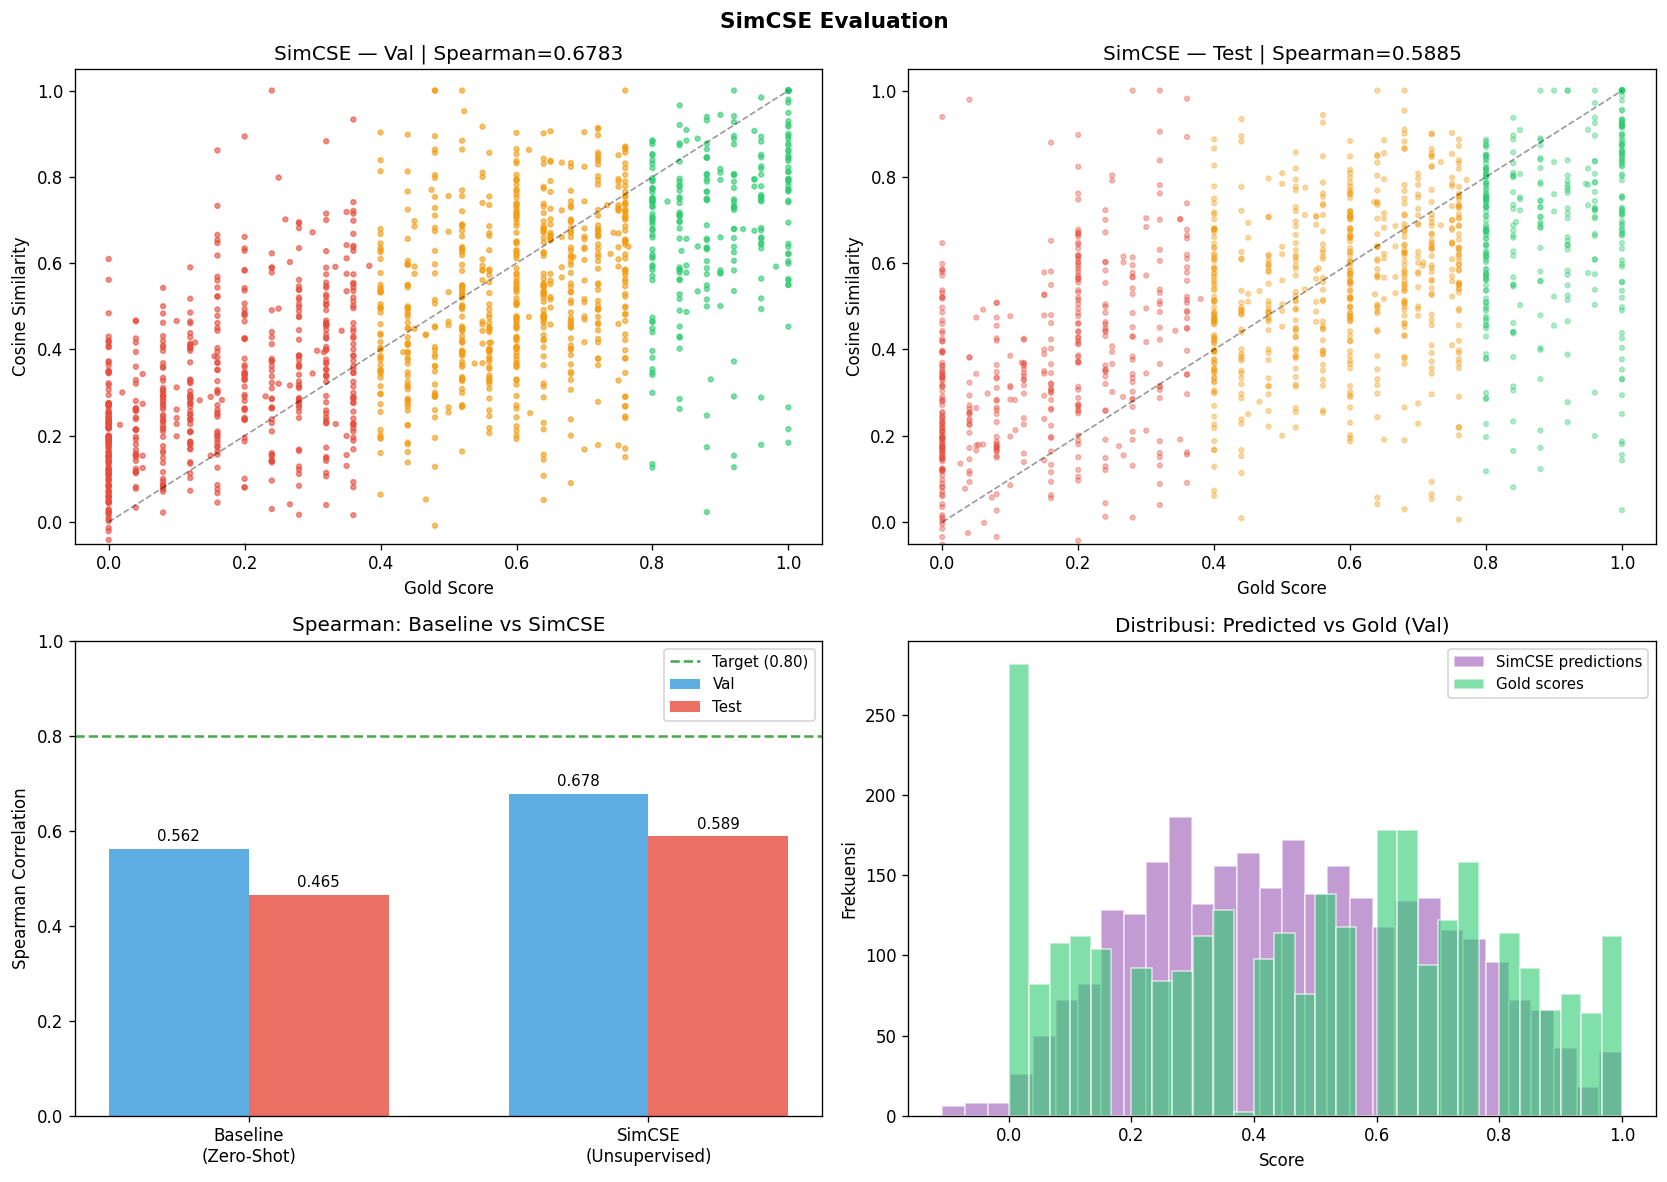

[OK] Plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/simcse_evaluation.png


In [10]:
# ============================================================
# CELL 4.5 - Evaluasi per Kategori & Visualisasi
# ============================================================

def eval_by_category(df, cos_scores):
    gold = df['score'].values
    cats = {
        'Low (0-2)'  : gold < 0.4,
        'Mid (2-4)'  : (gold >= 0.4) & (gold < 0.8),
        'High (4-5)' : gold >= 0.8
    }
    results = {}
    for name, mask in cats.items():
        if mask.sum() < 5: continue
        sp = spearmanr(gold[mask], cos_scores[mask]).statistic
        pe = pearsonr(gold[mask],  cos_scores[mask]).statistic
        results[name] = {
            'n'       : int(mask.sum()),
            'spearman': round(float(sp), 4),
            'pearson' : round(float(pe), 4)
        }
    return results

val_cat  = eval_by_category(df_val,  val_res['cos_scores'])
test_cat = eval_by_category(df_test, test_res['cos_scores'])

print("  Per-category Spearman:")
print(f"  {'Category':<14} {'Val N':>6}  {'Val Sp':>8}  {'Test N':>7}  {'Test Sp':>8}")
print(f"  {'-'*50}")
for cat in val_cat:
    v = val_cat.get(cat, {})
    t = test_cat.get(cat, {})
    print(f"  {cat:<14} {v.get('n',0):>6}  {v.get('spearman',0):>8.4f}  "
          f"{t.get('n',0):>7}  {t.get('spearman',0):>8.4f}")

# -- Visualisasi: 2x2 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SimCSE Evaluation', fontsize=13, fontweight='bold')

# Plot 1 & 2: Scatter gold vs predicted (val, test)
for ax, (df_sp, cos_sp, gold_sp, sp_name, sp_r) in zip(
    axes[0],
    [
        (df_val,  val_res['cos_scores'],  val_res['gold'],  'Val',  val_res['spearman']),
        (df_test, test_res['cos_scores'], test_res['gold'], 'Test', test_res['spearman']),
    ]
):
    colors = ['#e74c3c' if g < 0.4 else ('#f39c12' if g < 0.8 else '#2ecc71')
              for g in gold_sp]
    ax.scatter(gold_sp, cos_sp, c=colors, alpha=0.35, s=8)
    ax.plot([0,1],[0,1],'k--', alpha=0.4, linewidth=1)
    ax.set_xlabel('Gold Score')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'SimCSE — {sp_name} | Spearman={sp_r:.4f}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

# Plot 3: Baseline vs SimCSE bar chart
ax = axes[1, 0]
models_names = ['Baseline\n(Zero-Shot)', 'SimCSE\n(Unsupervised)']
val_scores   = [baseline_val_sp,  val_res['spearman']]
test_scores  = [baseline_test_sp, test_res['spearman']]
x = np.arange(len(models_names))
w = 0.35
bars1 = ax.bar(x - w/2, val_scores,  w, label='Val',  color='#3498db', alpha=0.8)
bars2 = ax.bar(x + w/2, test_scores, w, label='Test', color='#e74c3c', alpha=0.8)
ax.axhline(0.80, color='green', linestyle='--', alpha=0.7, label='Target (0.80)')
ax.set_ylabel('Spearman Correlation')
ax.set_title('Spearman: Baseline vs SimCSE')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Score distribution comparison
ax = axes[1, 1]
ax.hist(val_res['cos_scores'],  bins=30, alpha=0.6, label='SimCSE predictions',
        color='#9b59b6', edgecolor='white')
ax.hist(val_res['gold'],        bins=30, alpha=0.6, label='Gold scores',
        color='#2ecc71', edgecolor='white')
ax.set_xlabel('Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi: Predicted vs Gold (Val)')
ax.legend(fontsize=9)

plt.tight_layout()
plot_path = PATHS['evaluation'] / 'simcse_evaluation.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Plot tersimpan: {plot_path}")

In [11]:
# ============================================================
# CELL 4.6 - Simpan SimCSE Embeddings ke Drive
# ============================================================
# Simpan embeddings val + test agar bisa dipakai di Stage 10
# untuk comparison tanpa re-encode.

EMB_DIR = PATHS['embeddings']
EMB_DIR.mkdir(parents=True, exist_ok=True)

print("[INFO] Saving SimCSE embeddings...")
for split_name, res in [('val', val_res), ('test', test_res)]:
    np.save(EMB_DIR / f'simcse_{split_name}_emb_s1.npy', res['emb_s1'])
    np.save(EMB_DIR / f'simcse_{split_name}_emb_s2.npy', res['emb_s2'])
    np.save(EMB_DIR / f'simcse_{split_name}_scores.npy',  res['gold'])
    print(f"  [OK] simcse_{split_name}_emb_s1/s2.npy  shape={res['emb_s1'].shape}")

print(f"\n[OK] Semua embeddings tersimpan di: {EMB_DIR}")

[INFO] Saving SimCSE embeddings...
  [OK] simcse_val_emb_s1/s2.npy  shape=(2994, 768)
  [OK] simcse_test_emb_s1/s2.npy  shape=(1372, 768)

[OK] Semua embeddings tersimpan di: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/embeddings


In [12]:
# ============================================================
# CELL 4.7 - Simpan Hasil Evaluasi ke JSON & CSV
# ============================================================

simcse_eval = {
    'model_name'     : 'simcse_indobert',
    'base_model'     : 'indobenchmark/indobert-base-p1',
    'training_type'  : 'SimCSE unsupervised contrastive',
    'fine_tuned'     : True,
    'pooling'        : 'mean',
    'hyperparameters': {
        'batch_size'   : BATCH_SIZE,
        'epochs'       : NUM_EPOCHS,
        'learning_rate': LR,
        'warmup_ratio' : WARMUP_RATIO,
        'loss'         : 'MultipleNegativesRankingLoss',
        'scale'        : 20.0,
        'corpus_size'  : len(simcse_sentences),
    },
    'timestamp'      : datetime.datetime.now().isoformat(),
    'val': {
        'pearson'     : val_res['pearson'],
        'spearman'    : val_res['spearman'],
        'n_pairs'     : val_res['n_pairs'],
        'by_category' : val_cat,
        'delta_vs_baseline': round(val_res['spearman'] - baseline_val_sp, 4),
    },
    'test': {
        'pearson'     : test_res['pearson'],
        'spearman'    : test_res['spearman'],
        'n_pairs'     : test_res['n_pairs'],
        'by_category' : test_cat,
        'delta_vs_baseline': round(test_res['spearman'] - baseline_test_sp, 4),
    },
    'model_path'     : str(SIMCSE_OUTPUT),
}

# -- JSON
json_path = PATHS['evaluation'] / 'simcse_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(simcse_eval, f, indent=2, ensure_ascii=False)
print(f"[OK] Saved: {json_path}")

# -- CSV experiment log
log_path = SIMCSE_EXP / 'eval_log.csv'
pd.DataFrame([{
    'model'          : 'simcse_indobert',
    'val_pearson'    : val_res['pearson'],
    'val_spearman'   : val_res['spearman'],
    'test_pearson'   : test_res['pearson'],
    'test_spearman'  : test_res['spearman'],
    'delta_baseline' : round(test_res['spearman'] - baseline_test_sp, 4),
    'batch_size'     : BATCH_SIZE,
    'epochs'         : NUM_EPOCHS,
    'lr'             : LR,
    'timestamp'      : datetime.datetime.now().isoformat(),
}]).to_csv(log_path, index=False)
print(f"[OK] Saved: {log_path}")

# -- Final summary
print(f"\n{'='*55}")
print(f"  SIMCSE TRAINING RESULTS")
print(f"{'='*55}")
print(f"  {'Split':<8} {'Pearson':>10} {'Spearman':>10} {'Delta':>10}")
print(f"  {'-'*40}")
print(f"  {'Val':<8} {val_res['pearson']:>10.4f} {val_res['spearman']:>10.4f} "
      f"{val_res['spearman']-baseline_val_sp:>+10.4f}")
print(f"  {'Test':<8} {test_res['pearson']:>10.4f} {test_res['spearman']:>10.4f} "
      f"{test_res['spearman']-baseline_test_sp:>+10.4f}")
print(f"  {'-'*40}")
print(f"  Target  : >= 0.80 Spearman (achieved by SBERT)")
print(f"  Gap     : {0.80 - test_res['spearman']:+.4f}")
print(f"{'='*55}")

[OK] Saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/simcse_results.json
[OK] Saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/experiments/simcse/eval_log.csv

  SIMCSE TRAINING RESULTS
  Split       Pearson   Spearman      Delta
  ----------------------------------------
  Val          0.6748     0.6783    +0.1158
  Test         0.5929     0.5885    +0.1232
  ----------------------------------------
  Target  : >= 0.80 Spearman (achieved by SBERT)
  Gap     : +0.2115


In [13]:
# ============================================================
# CELL 4.8 - Sanity Check
# ============================================================

print("[INFO] Sanity check output Stage 4...\n")
import os
checks = []

# [1] Model saved
try:
    cfg = SIMCSE_OUTPUT / 'config.json'
    assert cfg.exists()
    sz = sum(os.path.getsize(os.path.join(dp,f))
             for dp,_,files in os.walk(SIMCSE_OUTPUT) for f in files) / 1e6
    checks.append(('models/simcse/', True, f'{sz:.0f} MB'))
except Exception as e:
    checks.append(('models/simcse/', False, str(e)))

# [2] Embeddings
for fname in ['simcse_val_emb_s1.npy','simcse_val_emb_s2.npy',
              'simcse_test_emb_s1.npy','simcse_test_emb_s2.npy']:
    try:
        arr = np.load(PATHS['embeddings'] / fname)
        assert arr.shape[1] == 768
        checks.append((fname, True, f'shape={arr.shape}'))
    except Exception as e:
        checks.append((fname, False, str(e)))

# [3] Results JSON
try:
    res = json.load(open(PATHS['evaluation'] / 'simcse_results.json'))
    assert res['test']['spearman'] > 0
    checks.append(('simcse_results.json', True,
                   f"test_spearman={res['test']['spearman']:.4f}"))
except Exception as e:
    checks.append(('simcse_results.json', False, str(e)))

# [4] Plot
try:
    assert (PATHS['evaluation'] / 'simcse_evaluation.png').exists()
    checks.append(('simcse_evaluation.png', True, 'plot saved'))
except Exception as e:
    checks.append(('simcse_evaluation.png', False, str(e)))

# Print
print(f"  {'File':<38} {'Status':<6}  Info")
print("  " + "-" * 65)
passed = 0
for fname, ok, info in checks:
    print(f"  {fname:<38} [{'OK' if ok else 'FAIL':<4}]  {info}")
    if ok: passed += 1

print("\n  " + "-" * 65)
print(f"  Result: {'ALL PASSED' if passed==len(checks) else f'{len(checks)-passed} FAILED'}  "
      f"({passed}/{len(checks)})")

print(f"\n{'='*55}")
print(f"  Stage 4 Complete!")
print(f"  SimCSE Test Spearman : {test_res['spearman']:.4f}")
print(f"  Delta vs Baseline    : {test_res['spearman']-baseline_test_sp:+.4f}")
print(f"  Next: 05_hard_negative_mining.ipynb")
print(f"{'='*55}")

[INFO] Sanity check output Stage 4...

  File                                   Status  Info
  -----------------------------------------------------------------
  models/simcse/                         [OK  ]  499 MB
  simcse_val_emb_s1.npy                  [OK  ]  shape=(2994, 768)
  simcse_val_emb_s2.npy                  [OK  ]  shape=(2994, 768)
  simcse_test_emb_s1.npy                 [OK  ]  shape=(1372, 768)
  simcse_test_emb_s2.npy                 [OK  ]  shape=(1372, 768)
  simcse_results.json                    [OK  ]  test_spearman=0.5885
  simcse_evaluation.png                  [OK  ]  plot saved

  -----------------------------------------------------------------
  Result: ALL PASSED  (7/7)

  Stage 4 Complete!
  SimCSE Test Spearman : 0.5885
  Delta vs Baseline    : +0.1232
  Next: 05_hard_negative_mining.ipynb


---

## Stage 4 Complete — Output Summary

```
MyDrive/AI-Projects/sts-indonesian-embeddings/
|
+-- models/simcse/                    <- best model checkpoint
+-- embeddings/
|   +-- simcse_val_emb_s1.npy         <- shape (2994, 768)
|   +-- simcse_val_emb_s2.npy
|   +-- simcse_val_scores.npy
|   +-- simcse_test_emb_s1.npy        <- shape (1372, 768)
|   +-- simcse_test_emb_s2.npy
|   +-- simcse_test_scores.npy
+-- evaluation/
|   +-- simcse_results.json
|   +-- simcse_evaluation.png
+-- experiments/simcse/
    +-- eval_log.csv
    +-- checkpoints/
```

### Expected SimCSE Performance
SimCSE unsupervised biasanya menghasilkan improvement **+0.05 – +0.15** Spearman dari zero-shot baseline.

### Estimasi Waktu Stage 4
| Sub-task | GPU T4 | CPU |
|----------|--------|-----|
| Load model | ~2 menit | ~2 menit |
| Training (1 epoch) | ~10-15 menit | ~3-4 jam |
| Evaluation | ~1 menit | ~5 menit |
| **Total** | **~15-20 menit** | **tidak disarankan** |

---
**Next:** `05_hard_negative_mining.ipynb` — BM25 Hard Negative Mining